# Emotion Detection - Using Deep Face

In [1]:
# pip install deepface

In [1]:
import os
os.getcwd()


'/content'

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import numpy as np

def deep_convert(obj):
    """Recursively convert numpy types and arrays to native Python types."""
    if isinstance(obj, dict):
        return {k: deep_convert(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [deep_convert(i) for i in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif obj is None:
        return None
    else:
        return obj


25-07-09 13:25:37 - Directory /root/.deepface has been created
25-07-09 13:25:37 - Directory /root/.deepface/weights has been created
25-07-09 13:25:40 - facial_expression_model_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 70.2MB/s]


Fully cleaned and saved analysis without NumPy internals.
     angry: 1.55%
   disgust: 0.00%
      fear: 73.61%
     happy: 2.17%
       sad: 0.00%
  surprise: 22.67%
   neutral: 0.00%


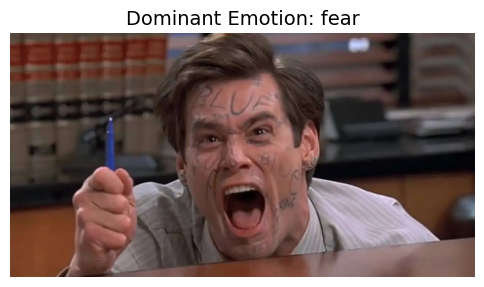

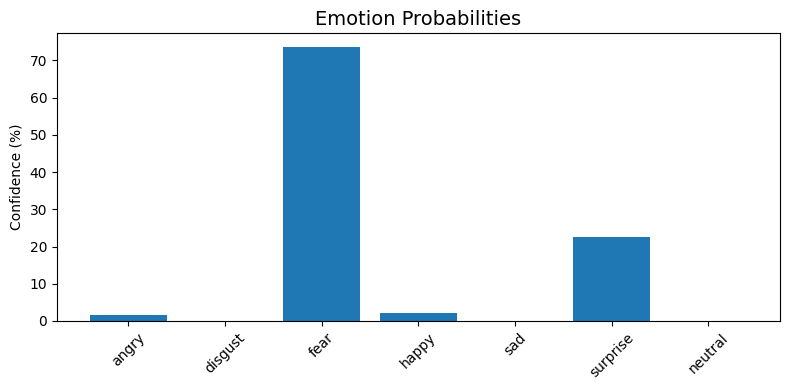

In [6]:
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt
import pickle

# Load and analyze the image
img_path = "/content/drive/MyDrive/emotion_detection/angry_face_1.jpg"
analysis = DeepFace.analyze(img_path=img_path, actions=["emotion"], enforce_detection=True)[0]

# Deep clean the output
analysis_cleaned = deep_convert(analysis)

# Save cleaned object
with open("/content/drive/MyDrive/emotion_detection/emotion_analysis_cleaned.pkl", "wb") as f:
    pickle.dump(analysis_cleaned, f)

print("Fully cleaned and saved analysis without NumPy internals.")


# Extract emotion results
emotions = analysis["emotion"]
dominant = analysis["dominant_emotion"]

for emo, score in emotions.items():
    print(f"{emo:>10}: {score:.2f}%")

# Display original image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"Dominant Emotion: {dominant}", fontsize=14)
plt.axis("off")
plt.show()

# Plot emotion probabilities
plt.figure(figsize=(8, 4))
plt.bar(emotions.keys(), emotions.values())
plt.title("Emotion Probabilities", fontsize=14)
plt.ylabel("Confidence (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
